In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
import os

os.listdir("../Data")

['Global_EV_Data.xlsx']

In [5]:
file_path = "../Data/Global_EV_Data.xlsx"

excel = pd.ExcelFile(file_path)

In [6]:
excel.sheet_names


['GEVO_EV_2026',
 'Notes',
 'Definitions',
 'Examples >>',
 'EV sales countries',
 'EV sales macro regions',
 'FCEV stock macro regions',
 'Other than sales and stock',
 'Regions and countries']

In [7]:
df = pd.read_excel(file_path, sheet_name="GEVO_EV_2026")


In [8]:
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Chile,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,1.0,Other
1,Norway,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,18.0,Other
2,Portugal,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,6.0,Other
3,Canada,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,2.0,Other
4,Chile,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,4.0,Other


In [9]:
df.shape

(49375, 9)

In [10]:
df.columns

Index(['region_country', 'category', 'parameter', 'mode', 'powertrain', 'year',
       'unit', 'value', 'Aggregate group'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49375 entries, 0 to 49374
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   48297 non-null  str    
 1   category         49375 non-null  str    
 2   parameter        49375 non-null  str    
 3   mode             49375 non-null  str    
 4   powertrain       49375 non-null  str    
 5   year             49375 non-null  int64  
 6   unit             26793 non-null  str    
 7   value            49375 non-null  float64
 8   Aggregate group  49375 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 3.4 MB


In [12]:
df.isnull().sum()

region_country      1078
category               0
parameter              0
mode                   0
powertrain             0
year                   0
unit               22582
value                  0
Aggregate group        0
dtype: int64

In [13]:
df["parameter"].value_counts()

parameter
EV stock                            7891
EV sales                            7647
price_p0_2025USD                    3226
price_p100_2025USD                  3226
price_p25_2025USD                   3226
price_p50_2025USD                   3226
price_p75_2025USD                   3226
price_p95_2025USD                   3226
price_mean_2025USD                  3226
EV sales share                      2833
EV stock share                      2777
EV charging points                  1457
Oil displacement Mlge                622
Oil displacement, Mbd                622
Average capacity per EVSE            602
Electric LDVs per charging point     601
Average capacity per EV              601
Electricity demand                   594
Battery deployment                   546
Name: count, dtype: int64

In [14]:
df["category"].value_counts()

category
Historical          48114
Projection-STEPS      640
Projection-CPS        621
Name: count, dtype: int64

In [15]:
sorted(df["year"].unique())

[np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025),
 np.int64(2035)]

In [16]:
df.duplicated().sum()

np.int64(15)

In [17]:
df[df.duplicated()]

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
19352,United Arab Emirates,Historical,Electric LDVs per charging point,EV,EV,2021,vehicles,49.000,Other
19355,United Arab Emirates,Historical,Electric LDVs per charging point,EV,EV,2022,vehicles,120.000,Other
19359,United Arab Emirates,Historical,Electric LDVs per charging point,EV,EV,2023,vehicles,220.000,Other
19363,United Arab Emirates,Historical,Electric LDVs per charging point,EV,EV,2024,vehicles,280.000,Other
19367,United Arab Emirates,Historical,Electric LDVs per charging point,EV,EV,2025,vehicles,160.000,Other
19805,United Arab Emirates,Historical,Average capacity per EV,EV,EV,2021,kW/EV,0.310,Other
19808,United Arab Emirates,Historical,Average capacity per EV,EV,EV,2022,kW/EV,0.120,Other
19812,United Arab Emirates,Historical,Average capacity per EV,EV,EV,2023,kW/EV,0.069,Other
19816,United Arab Emirates,Historical,Average capacity per EV,EV,EV,2024,kW/EV,0.054,Other
19820,United Arab Emirates,Historical,Average capacity per EV,EV,EV,2025,kW/EV,0.096,Other


In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df[df["region_country"].isna()]

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
20772,NaN,Historical,price_p0_2025USD,City car,ICEV,2010,NaN,4900.0,Other
20773,NaN,Historical,price_p0_2025USD,Large car,ICEV,2010,NaN,8500.0,Other
20774,NaN,Historical,price_p0_2025USD,Large SUV/Pick-up,ICEV,2010,NaN,26000.0,Other
20775,NaN,Historical,price_p0_2025USD,Medium car,ICEV,2010,NaN,4900.0,Other
20776,NaN,Historical,price_p0_2025USD,Small SUV/Pick-up,ICEV,2010,NaN,7200.0,Other
...,...,...,...,...,...,...,...,...,...
43199,NaN,Historical,price_mean_2025USD,All cars,ALL,2017,NaN,23000.0,Other
43216,NaN,Historical,price_mean_2025USD,All cars,ALL,2018,NaN,26000.0,Other
43233,NaN,Historical,price_mean_2025USD,All cars,ALL,2019,NaN,26000.0,Other
43248,NaN,Historical,price_mean_2025USD,All cars,ALL,2021,NaN,22000.0,Other


In [22]:
df_original = df.copy()

In [23]:
df = df.dropna(subset=["region_country"])

In [24]:
df.shape

(48282, 9)

In [25]:
df["region_country"].isnull().sum()

np.int64(0)

In [26]:
df.to_csv("../Data/EV_Cleaned.csv", index=False)

In [27]:
df_original = df.copy()

In [28]:
df = df.dropna(subset=["region_country"])

In [29]:
df.shape

(48282, 9)

In [30]:
df["region_country"].isnull().sum()

np.int64(0)

In [32]:
df.to_csv("../Data/EV_Cleaned.csv", index=False)

In [33]:
ev = df.copy()

In [34]:
important_parameters = [
    "EV sales",
    "EV stock",
    "EV sales share",
    "EV stock share",
    "EV charging points"
]

ev = ev[ev["parameter"].isin(important_parameters)]

In [35]:
ev["parameter"].value_counts()


parameter
EV stock              7891
EV sales              7647
EV sales share        2833
EV stock share        2777
EV charging points    1457
Name: count, dtype: int64

In [36]:
ev.shape

(22605, 9)

In [37]:
ev_sales = ev[ev["parameter"] == "EV sales"]

In [38]:
ev_sales.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
915,Iceland,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,1.0,Other
916,Israel,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,11.0,Other
917,New Zealand,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,14.0,Other
918,Thailand,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,590.0,Other
919,United Kingdom,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,550.0,Other


In [39]:
ev_sales["mode"].value_counts()

mode
Cars                3009
2 and 3 wheelers    1364
Vans                1353
Buses               1168
Trucks               753
Name: count, dtype: int64

In [40]:
ev_sales["powertrain"].value_counts()

powertrain
EV      2840
BEV     2828
PHEV    1307
FCEV     672
Name: count, dtype: int64

In [1]:
ev_sales["mode"].value_counts()

NameError: name 'ev_sales' is not defined

In [2]:
cars = ev[
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
]

NameError: name 'ev' is not defined

In [3]:
df.head()

NameError: name 'df' is not defined

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../Data/EV_Cleaned.csv")

In [6]:
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Chile,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,1.0,Other
1,Norway,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,18.0,Other
2,Portugal,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,6.0,Other
3,Canada,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,2.0,Other
4,Chile,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,4.0,Other


In [7]:
important_parameters = [
    "EV sales",
    "EV stock",
    "EV sales share",
    "EV stock share",
    "EV charging points"
]

ev = df[df["parameter"].isin(important_parameters)].copy()

In [8]:
cars = ev[
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
].copy()

In [9]:
cars.shape

(3248, 9)

In [10]:
sales_2025 = ev[
    (ev["parameter"] == "EV sales") &
    (ev["category"] == "Historical") &
    (ev["year"] == 2025)
].copy()

In [11]:
sales_2025.shape

(620, 9)

In [12]:
top10 = (
    sales_2025
    .groupby("region_country")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10

region_country
World                               66101012.0
Asia Pacific                        51826300.0
China                               42272035.0
Advanced Economies                  14324895.0
Europe                               9504184.0
Developing Economies excl. China     9081926.0
European Union                       6310563.0
India                                4567195.0
USA                                  3062170.0
Southeast Asia                       2851243.0
Name: value, dtype: float64

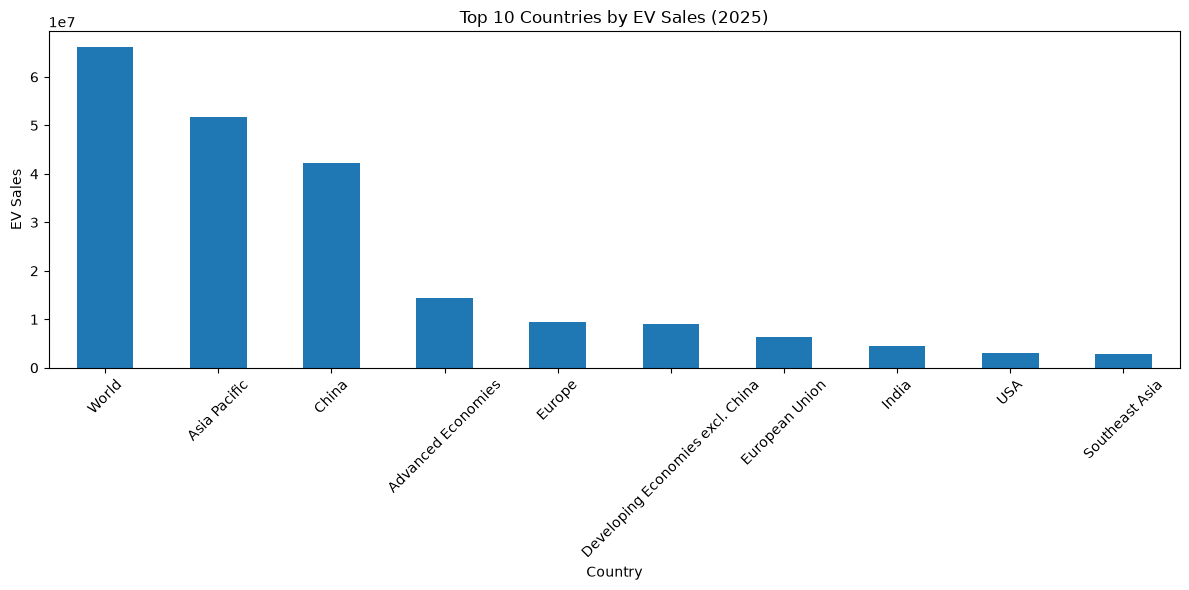

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10.plot(kind="bar")

plt.title("Top 10 Countries by EV Sales (2025)")
plt.xlabel("Country")
plt.ylabel("EV Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [14]:
sales_2025["Aggregate group"].value_counts()

Aggregate group
Other                 414
Other_aggregate        73
Projection_country     56
Projection_region      43
_World                 18
European Union         16
Name: count, dtype: int64

In [15]:
sales_2025["region_country"].nunique()

70

In [16]:
sales_2025["region_country"].sort_values().unique()

<StringArray>
[              'Advanced Economies',                           'Africa',
                     'Asia Pacific',                        'Australia',
                          'Austria',                          'Belgium',
                           'Brazil',                         'Bulgaria',
                         'Cambodia',                           'Canada',
                            'Chile',                            'China',
                         'Colombia',                       'Costa Rica',
                          'Croatia',                           'Cyprus',
                   'Czech Republic',                          'Denmark',
 'Developing Economies excl. China',                          'Estonia',
                           'Europe',                   'European Union',
                          'Finland',                           'France',
                          'Germany',                           'Greece',
                          'Hungary', 

In [17]:
aggregates = [
    "World",
    "Europe",
    "European Union",
    "Asia Pacific",
    "Latin America",
    "Africa",
    "Middle East and Caspian",
    "Developing Economies excl. China",
    "Advanced Economies",
    "Southeast Asia"
]

In [18]:
countries_2025 = sales_2025[
    ~sales_2025["region_country"].isin(aggregates)
].copy()

In [19]:
top10_countries = (
    countries_2025
    .groupby("region_country")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_countries

region_country
China             42272035.0
India              4567195.0
USA                3062170.0
Viet Nam           1840297.0
Germany            1812807.0
United Kingdom     1492316.0
France             1008280.0
Turkiye             817000.0
Netherlands         518598.0
Spain               503363.0
Name: value, dtype: float64

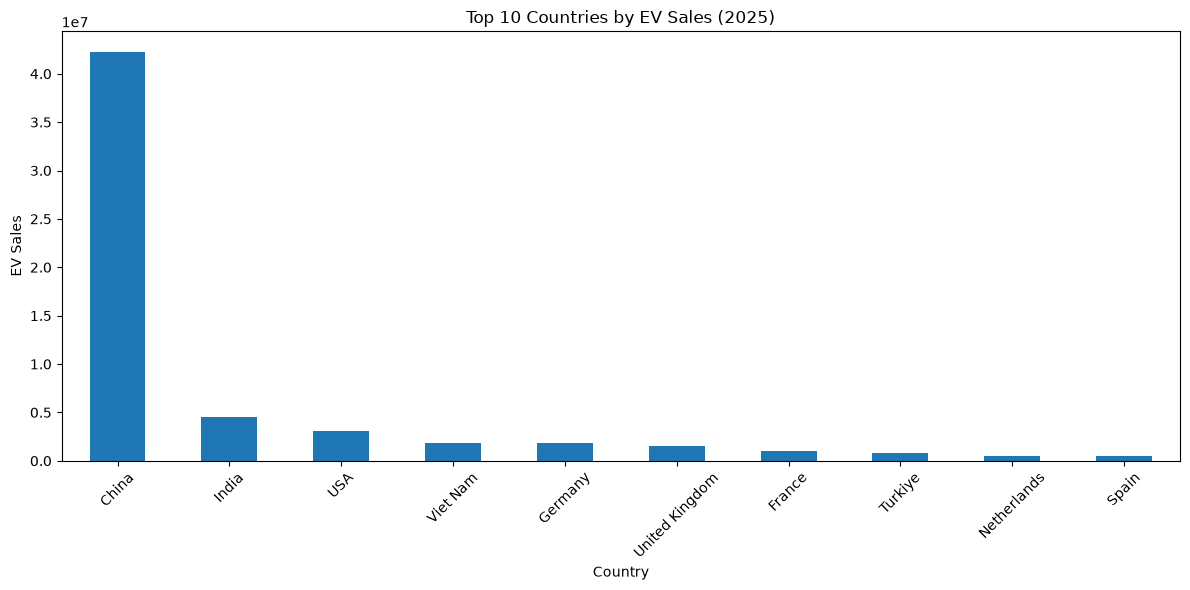

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10_countries.plot(kind="bar")

plt.title("Top 10 Countries by EV Sales (2025)")
plt.xlabel("Country")
plt.ylabel("EV Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

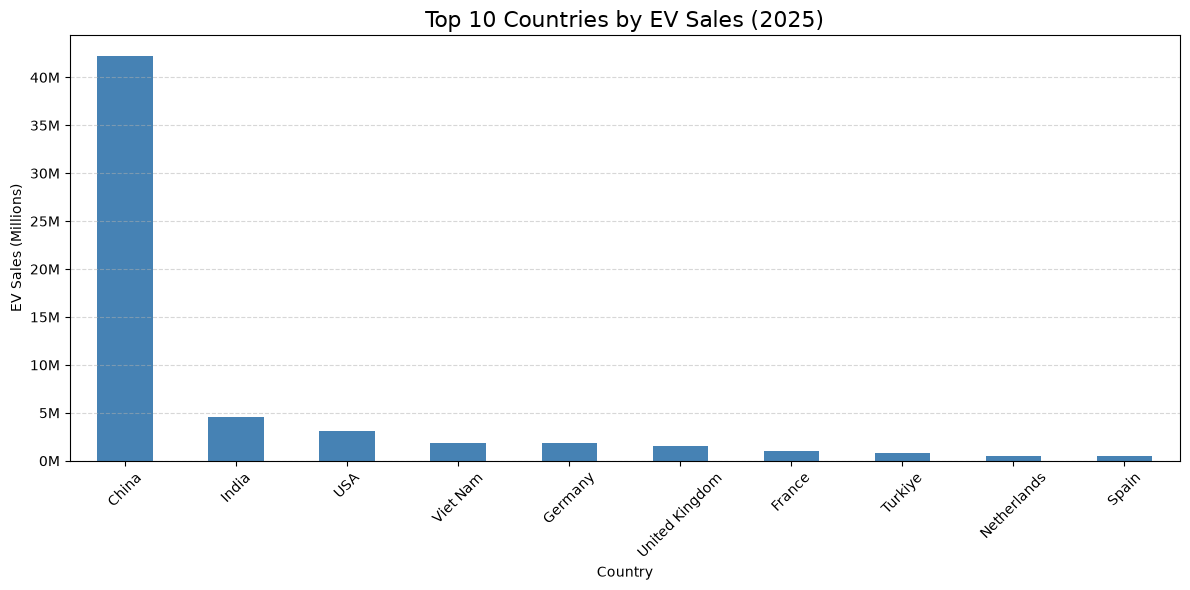

In [21]:

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

top10_countries.plot(kind="bar", color="steelblue")

plt.title("Top 10 Countries by EV Sales (2025)", fontsize=16)
plt.xlabel("Country")
plt.ylabel("EV Sales (Millions)")

plt.xticks(rotation=45)

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.0f}M')
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

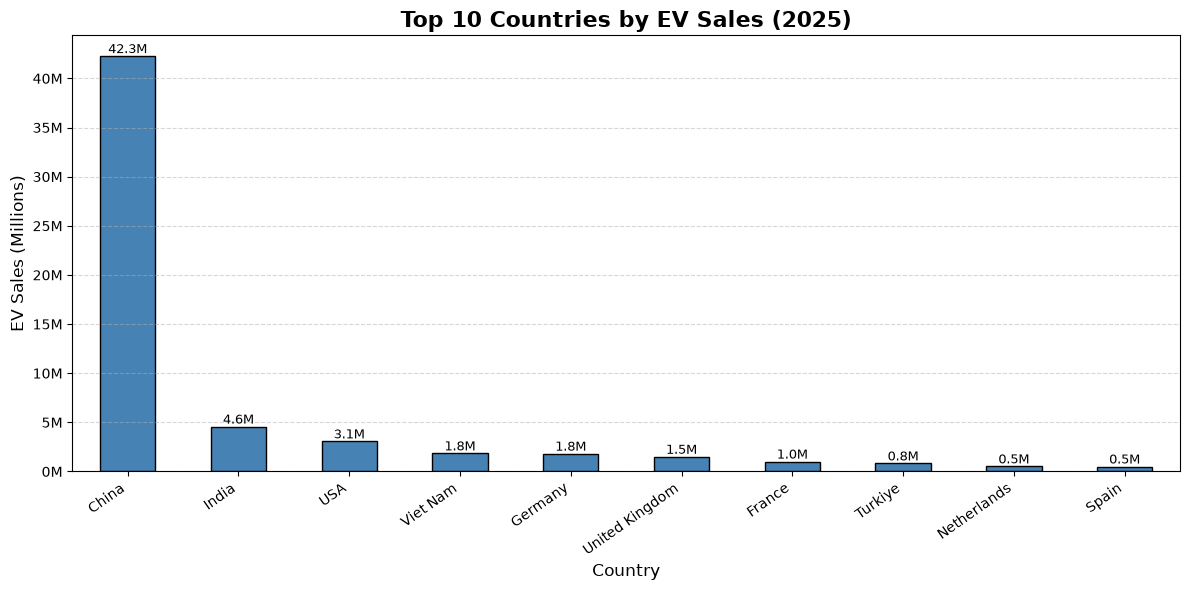

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

ax = top10_countries.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by EV Sales (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("EV Sales (Millions)", fontsize=12)

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add data labels
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{height/1_000_000:.1f}M",
        (bar.get_x() + bar.get_width()/2, height),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Global EV Sales Trend (2010–2025)

In [1]:
global_sales = ev[
    (ev["parameter"] == "EV sales") &
    (ev["region_country"] == "World") &
    (ev["category"] == "Historical")
].copy()

NameError: name 'ev' is not defined

In [2]:
df.head()

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_excel("../Data/Global_EV_Data.xlsx", sheet_name="GEVO_EV_2026")


In [4]:
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Chile,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,1.0,Other
1,Norway,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,18.0,Other
2,Portugal,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,6.0,Other
3,Canada,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,2.0,Other
4,Chile,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,4.0,Other


In [5]:
df = df.dropna(subset=["region_country"]).copy()

In [6]:
important_parameters = [
    "EV sales",
    "EV stock",
    "EV sales share",
    "EV stock share",
    "EV charging points"
]

ev = df[df["parameter"].isin(important_parameters)].copy()

In [7]:
ev.shape

(22605, 9)

In [8]:
global_sales = ev[
    (ev["parameter"] == "EV sales") &
    (ev["region_country"] == "World") &
    (ev["category"] == "Historical")
].copy()

global_sales = global_sales.sort_values("year")

In [9]:
global_sales

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
6496,World,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,41000.0,_World
49243,World,Historical,EV sales,Trucks,EV,2010,Vehicles,37.0,_World
49227,World,Historical,EV sales,Cars,EV,2010,Vehicles,7400.0,_World
6553,World,Historical,EV sales,Cars,BEV,2010,Vehicles,7000.0,_World
49211,World,Historical,EV sales,Buses,EV,2010,Vehicles,1100.0,_World
...,...,...,...,...,...,...,...,...,...
6568,World,Historical,EV sales,Cars,BEV,2025,Vehicles,14000000.0,_World
49242,World,Historical,EV sales,Cars,EV,2025,Vehicles,21000000.0,_World
6615,World,Historical,EV sales,Trucks,BEV,2025,Vehicles,430000.0,_World
6599,World,Historical,EV sales,Cars,PHEV,2025,Vehicles,7200000.0,_World


In [10]:
global_car_sales = ev[
    (ev["parameter"] == "EV sales") &
    (ev["region_country"] == "World") &
    (ev["category"] == "Historical") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
].copy()

In [11]:
global_car_sales

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
6553,World,Historical,EV sales,Cars,BEV,2010,Vehicles,7000.0,_World
6554,World,Historical,EV sales,Cars,BEV,2011,Vehicles,40000.0,_World
6555,World,Historical,EV sales,Cars,BEV,2012,Vehicles,59000.0,_World
6556,World,Historical,EV sales,Cars,BEV,2013,Vehicles,110000.0,_World
6557,World,Historical,EV sales,Cars,BEV,2014,Vehicles,200000.0,_World
6558,World,Historical,EV sales,Cars,BEV,2015,Vehicles,330000.0,_World
6559,World,Historical,EV sales,Cars,BEV,2016,Vehicles,470000.0,_World
6560,World,Historical,EV sales,Cars,BEV,2017,Vehicles,760000.0,_World
6561,World,Historical,EV sales,Cars,BEV,2018,Vehicles,1400000.0,_World
6562,World,Historical,EV sales,Cars,BEV,2019,Vehicles,1500000.0,_World


In [12]:
global_sales_yearly = (
    global_car_sales
    .groupby("year")["value"]
    .sum()
    .reset_index()
)

global_sales_yearly

,year,value
0,2010,7450.0
1,2011,49000.0
2,2012,119000.0
3,2013,201000.0
4,2014,330000.0
5,2015,520000.0
6,2016,780000.0
7,2017,1200000.0
8,2018,2050000.0
9,2019,2080000.0


In [13]:
global_sales_yearly.shape

(16, 2)

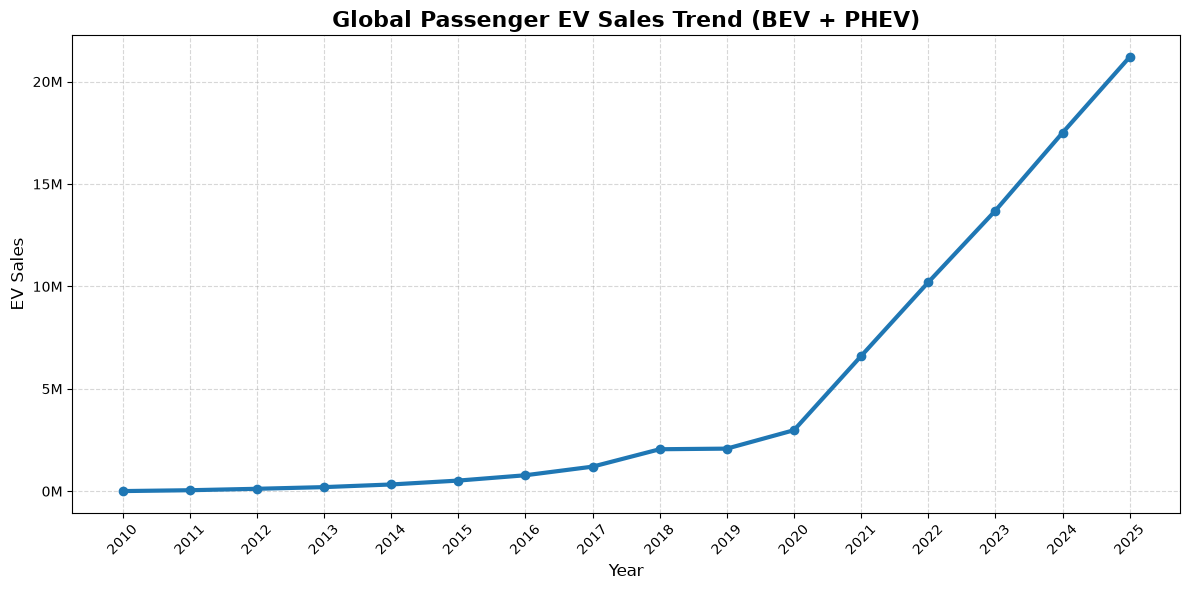

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

plt.plot(
    global_sales_yearly["year"],
    global_sales_yearly["value"],
    marker="o",
    linewidth=3
)

plt.title(
    "Global Passenger EV Sales Trend (BEV + PHEV)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("EV Sales", fontsize=12)

# Format Y-axis in Millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.xticks(global_sales_yearly["year"], rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Business Insights

- Global passenger EV sales increased from approximately **7,450 vehicles in 2010** to **21.2 million vehicles in 2025**.
- The market experienced rapid acceleration after **2020**, driven by government incentives, battery cost reductions, and increased consumer demand.
- The strongest growth period occurred between **2021 and 2025**, indicating mass adoption of electric vehicles.
- The trend suggests that EVs are transitioning from an emerging technology to a mainstream transportation solution.

# China vs India vs USA EV Sales (2010–2025)

comparison = ev[
    (ev["parameter"] == "EV sales") &
    (ev["category"] == "Historical") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV") &
    (ev["region_country"].isin(["China", "India", "USA"]))
].copy()

comparison.head()

In [15]:
comparison = ev[
    (ev["parameter"] == "EV sales") &
    (ev["category"] == "Historical") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV") &
    (ev["region_country"].isin(["China", "India", "USA"]))
].copy()

comparison.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
44686,China,Historical,EV sales,Cars,EV,2010,Vehicles,1400.0,Projection_country
44687,China,Historical,EV sales,Cars,EV,2011,Vehicles,5100.0,Projection_country
44688,China,Historical,EV sales,Cars,EV,2012,Vehicles,9900.0,Projection_country
44689,China,Historical,EV sales,Cars,EV,2013,Vehicles,16000.0,Projection_country
44690,China,Historical,EV sales,Cars,EV,2014,Vehicles,74000.0,Projection_country


In [16]:
comparison.shape

(48, 9)

In [17]:
comparison_pivot = comparison.pivot(
    index="year",
    columns="region_country",
    values="value"
)

comparison_pivot

region_country,China,India,USA
year,,,
2010,1400.0,450.0,1200.0
2011,5100.0,1400.0,18000.0
2012,9900.0,190.0,53000.0
2013,16000.0,410.0,97000.0
2014,74000.0,1000.0,120000.0
2015,210000.0,450.0,110000.0
2016,340000.0,730.0,160000.0
2017,580000.0,920.0,200000.0
2018,1100000.0,920.0,360000.0


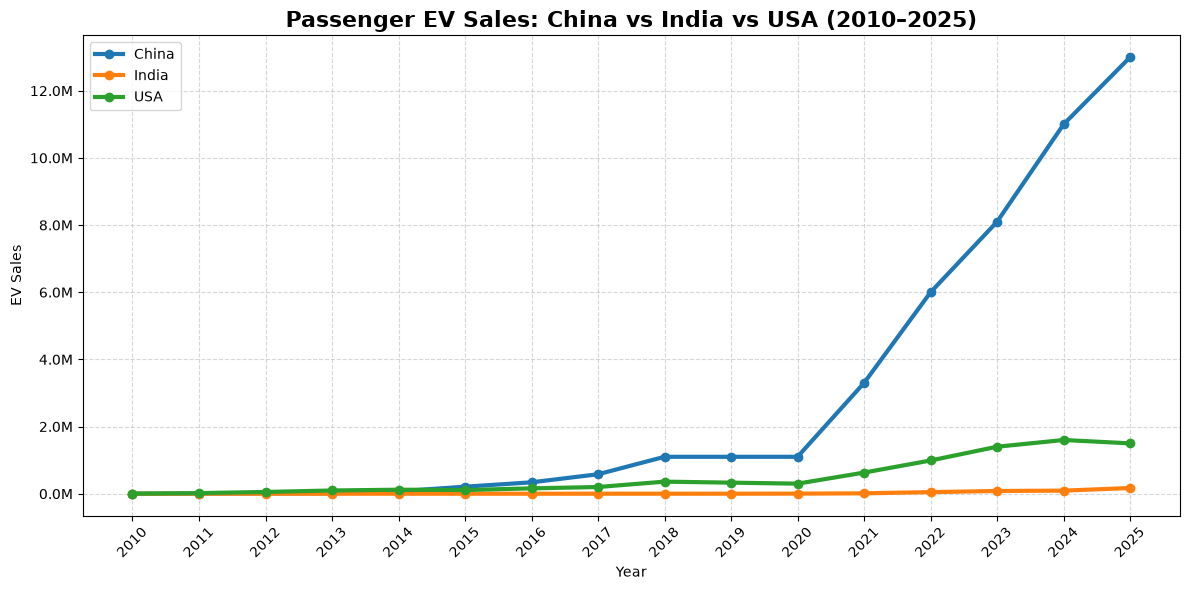

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

plt.plot(
    comparison_pivot.index,
    comparison_pivot["China"],
    marker="o",
    linewidth=3,
    label="China"
)

plt.plot(
    comparison_pivot.index,
    comparison_pivot["India"],
    marker="o",
    linewidth=3,
    label="India"
)

plt.plot(
    comparison_pivot.index,
    comparison_pivot["USA"],
    marker="o",
    linewidth=3,
    label="USA"
)

plt.title(
    "Passenger EV Sales: China vs India vs USA (2010–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("EV Sales")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

plt.xticks(comparison_pivot.index, rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()

## Business Insights

- China dominates global EV sales throughout the period and shows explosive growth after 2020.
- The USA demonstrates steady growth but remains significantly behind China.
- India shows rapid recent growth, indicating an emerging high-potential EV market.
- The comparison highlights China's leadership while emphasizing India's strong future growth opportunity.

# Global BEV vs PHEV Sales Trend (2010–2025)

bev_phev = ev[
    (ev["parameter"] == "EV sales") &
    (ev["category"] == "Historical") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
].copy()

bev_phev.head()

In [19]:
bev_phev = ev[
    (ev["parameter"] == "EV sales") &
    (ev["category"] == "Historical") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
].copy()

bev_phev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
6553,World,Historical,EV sales,Cars,BEV,2010,Vehicles,7000.0,_World
6554,World,Historical,EV sales,Cars,BEV,2011,Vehicles,40000.0,_World
6555,World,Historical,EV sales,Cars,BEV,2012,Vehicles,59000.0,_World
6556,World,Historical,EV sales,Cars,BEV,2013,Vehicles,110000.0,_World
6557,World,Historical,EV sales,Cars,BEV,2014,Vehicles,200000.0,_World


In [20]:
bev_phev.shape

(32, 9)

In [21]:
bev_phev_pivot = bev_phev.pivot(
    index="year",
    columns="powertrain",
    values="value"
)

bev_phev_pivot

powertrain,BEV,PHEV
year,,
2010,7000.0,450.0
2011,40000.0,9000.0
2012,59000.0,60000.0
2013,110000.0,91000.0
2014,200000.0,130000.0
2015,330000.0,190000.0
2016,470000.0,310000.0
2017,760000.0,440000.0
2018,1400000.0,650000.0


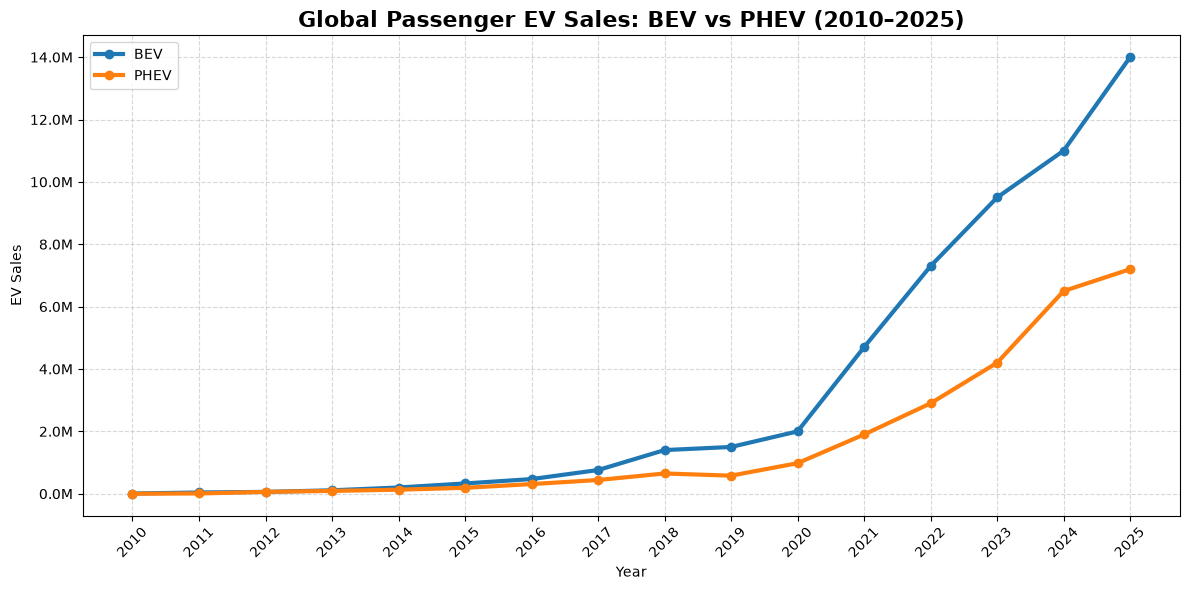

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

plt.plot(
    bev_phev_pivot.index,
    bev_phev_pivot["BEV"],
    marker="o",
    linewidth=3,
    label="BEV"
)

plt.plot(
    bev_phev_pivot.index,
    bev_phev_pivot["PHEV"],
    marker="o",
    linewidth=3,
    label="PHEV"
)

plt.title(
    "Global Passenger EV Sales: BEV vs PHEV (2010–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("EV Sales")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

plt.xticks(bev_phev_pivot.index, rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()

## Business Insights

- BEV sales have consistently outpaced PHEV sales since 2010.
- After 2020, BEV adoption accelerated significantly, reflecting improvements in battery technology, charging infrastructure, and government incentives.
- PHEVs continued to grow but at a slower pace than BEVs.
- The widening gap suggests that the global market is increasingly favoring fully electric vehicles over plug-in hybrids.

# Global EV Stock Growth (2010–2025)

stock = ev[
    (ev["parameter"] == "EV stock") &
    (ev["category"] == "Historical") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV")
].copy()

stock = stock.sort_values("year")

stock.head()

In [23]:
stock = ev[
    (ev["parameter"] == "EV stock") &
    (ev["category"] == "Historical") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV")
].copy()

stock = stock.sort_values("year")

stock.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
49307,World,Historical,EV stock,Cars,EV,2010,Vehicles,39000.0,_World
49308,World,Historical,EV stock,Cars,EV,2011,Vehicles,95000.0,_World
49309,World,Historical,EV stock,Cars,EV,2012,Vehicles,220000.0,_World
49310,World,Historical,EV stock,Cars,EV,2013,Vehicles,420000.0,_World
49311,World,Historical,EV stock,Cars,EV,2014,Vehicles,730000.0,_World


In [24]:
stock.shape

(16, 9)

# Global EV Stock Growth (2010–2025)

In [25]:
stock = ev[
    (ev["parameter"] == "EV stock") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV") &
    (ev["category"] == "Historical")
].copy()

stock = stock.sort_values("year")

stock[["year", "value"]]

,year,value
49307,2010,39000.0
49308,2011,95000.0
49309,2012,220000.0
49310,2013,420000.0
49311,2014,730000.0
49312,2015,1300000.0
49313,2016,2000000.0
49314,2017,3200000.0
49315,2018,5100000.0
49316,2019,7100000.0


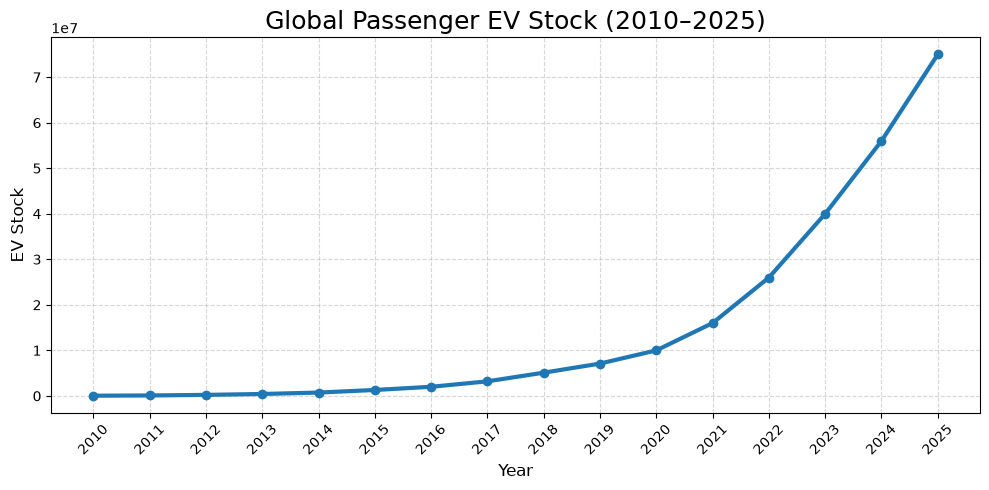

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    stock["year"],
    stock["value"],
    marker="o",
    linewidth=3
)

plt.title("Global Passenger EV Stock (2010–2025)", fontsize=18)
plt.xlabel("Year", fontsize=12)
plt.ylabel("EV Stock", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(stock["year"], rotation=45)

plt.tight_layout()

plt.show()


In [27]:
# Business Insights

- Global passenger EV stock increased from approximately **39 thousand vehicles in 2010** to **75 million vehicles in 2025**.
- The total number of EVs on the road grew nearly **1,900 times** over 15 years.
- The strongest acceleration occurred after **2020**, indicating rapid worldwide EV adoption.
- The continuous increase in EV stock highlights long-term market expansion and increasing consumer confidence.

SyntaxError: invalid syntax (518168385.py, line 3)

# Business Insights

- Global passenger EV stock increased from approximately **39 thousand vehicles in 2010** to **75 million vehicles in 2025**.
- The total number of EVs on the road grew nearly **1,900 times** over 15 years.
- The strongest acceleration occurred after **2020**, indicating rapid worldwide EV adoption.
- The continuous increase in EV stock highlights long-term market expansion and increasing consumer confidence.

# Global EV Charging Infrastructure Growth (2011–2025)

In [28]:
charging = ev[
    (ev["parameter"] == "EV charging points") &
    (ev["region_country"] == "World") &
    (ev["powertrain"] == "Publicly available fast") &
    (ev["category"] == "Historical")
].copy()

charging = charging.sort_values("year")

charging[["year", "value"]]

,year,value
6452,2010,310.0
6453,2011,830.0
6454,2012,1600.0
6455,2013,2600.0
6456,2014,13000.0
6457,2015,25000.0
6458,2016,72000.0
6459,2017,100000.0
6460,2018,140000.0
6461,2019,200000.0


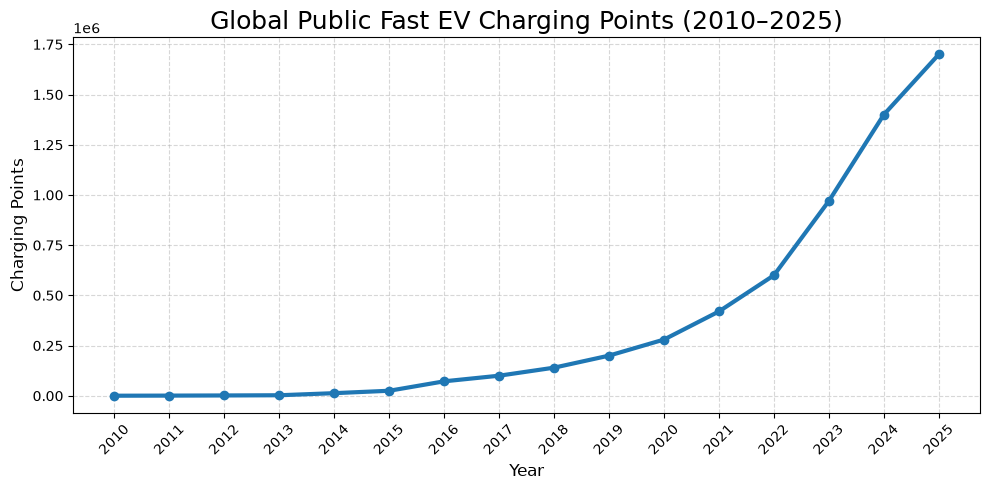

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    charging["year"],
    charging["value"],
    marker="o",
    linewidth=3
)

plt.title("Global Public Fast EV Charging Points (2010–2025)", fontsize=18)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Charging Points", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(charging["year"], rotation=45)

plt.tight_layout()

plt.show()

# Business Insights

- Global public fast EV charging points increased from **310 in 2010** to **1.7 million in 2025**.
- Charging infrastructure expanded rapidly after **2020**, supporting the accelerating adoption of electric vehicles.
- The strong growth in charging networks reduces range anxiety and improves EV accessibility.
- Continued investment in charging infrastructure is essential to sustain future EV market growth.

In [30]:
# Global EV Market Share (2010–2025)

# Global EV Market Share (2010–2025)

In [31]:
market_share = ev[
    (ev["parameter"] == "EV sales share") &
    (ev["region_country"] == "World") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"] == "EV") &
    (ev["category"] == "Historical")
].copy()

market_share = market_share.sort_values("year")

market_share[["year", "value"]]

,year,value
18245,2010,0.012
18246,2011,0.072
18247,2012,0.170
18248,2013,0.290
18249,2014,0.440
18250,2015,0.680
18251,2016,0.950
18252,2017,1.400
18253,2018,2.500
18254,2019,2.700


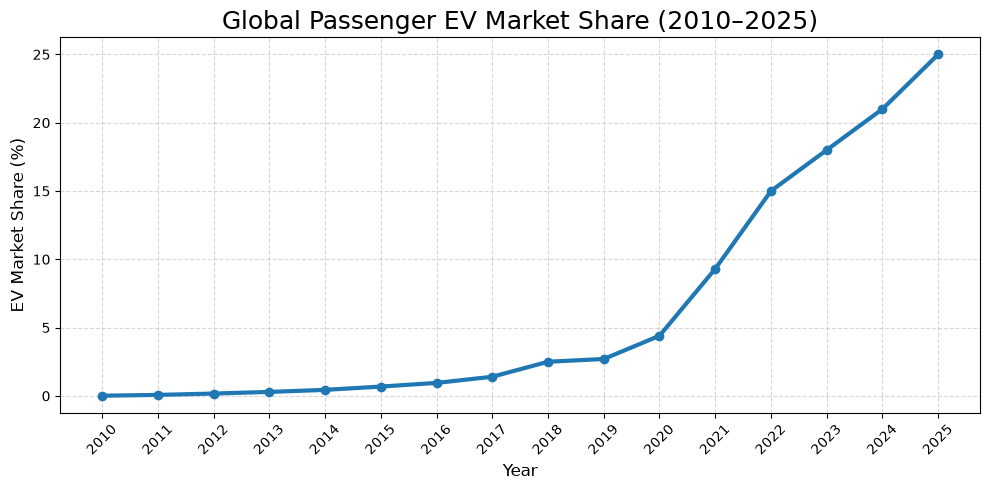

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    market_share["year"],
    market_share["value"],
    marker="o",
    linewidth=3
)

plt.title("Global Passenger EV Market Share (2010–2025)", fontsize=18)
plt.xlabel("Year", fontsize=12)
plt.ylabel("EV Market Share (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(market_share["year"], rotation=45)

plt.tight_layout()

plt.show()

# Business Insights

- Global passenger EV market share increased from **0.012% in 2010** to **25% in 2025**.
- EV adoption accelerated rapidly after **2020**, driven by government incentives, battery cost reductions, and expanding charging infrastructure.
- By **2025**, one out of every four new passenger cars sold globally is an electric vehicle.
- The consistent rise in market share indicates that EVs are transitioning from a niche product to a mainstream transportation solution.

# 🌍 Top 10 Countries by EV Market Share (2025)

In [33]:
market_share = ev[
    (ev["parameter"] == "EV sales share") &
    (ev["category"] == "Historical") &
    (ev["year"] == 2025)
].copy()

market_share = market_share.sort_values("value", ascending=False)

market_share.head(10)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
17903,United Arab Emirates,Historical,EV sales share,Vans,EV,2025,percent,210.0,Other
16566,Norway,Historical,EV sales share,Cars,EV,2025,percent,97.0,Other
16381,Netherlands,Historical,EV sales share,Vans,EV,2025,percent,84.0,Other
14258,Denmark,Historical,EV sales share,Cars,EV,2025,percent,71.0,Other
14228,Denmark,Historical,EV sales share,Buses,EV,2025,percent,71.0,Other
18814,Nepal,Historical,EV sales share,Cars,EV,2025,percent,68.0,Other
15295,Iceland,Historical,EV sales share,Cars,EV,2025,percent,62.0,Other
13984,China,Historical,EV sales share,Buses,EV,2025,percent,62.0,Projection_country
16540,Norway,Historical,EV sales share,Buses,EV,2025,percent,62.0,Other
17436,Sweden,Historical,EV sales share,Cars,EV,2025,percent,61.0,Other


In [34]:
market_share = ev[
    (ev["parameter"] == "EV sales share") &
    (ev["category"] == "Historical") &
    (ev["year"] == 2025) &
    (ev["mode"] == "Cars")
].copy()

market_share = market_share.sort_values("value", ascending=False)

market_share.head(10)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
16566,Norway,Historical,EV sales share,Cars,EV,2025,percent,97.0,Other
14258,Denmark,Historical,EV sales share,Cars,EV,2025,percent,71.0,Other
18814,Nepal,Historical,EV sales share,Cars,EV,2025,percent,68.0,Other
15295,Iceland,Historical,EV sales share,Cars,EV,2025,percent,62.0,Other
17436,Sweden,Historical,EV sales share,Cars,EV,2025,percent,61.0,Other
16322,Netherlands,Historical,EV sales share,Cars,EV,2025,percent,58.0,Other
14866,Finland,Historical,EV sales share,Cars,EV,2025,percent,57.0,Other
14016,China,Historical,EV sales share,Cars,EV,2025,percent,53.0,Projection_country
13636,Belgium,Historical,EV sales share,Cars,EV,2025,percent,44.0,Other
17001,Singapore,Historical,EV sales share,Cars,EV,2025,percent,40.0,Other


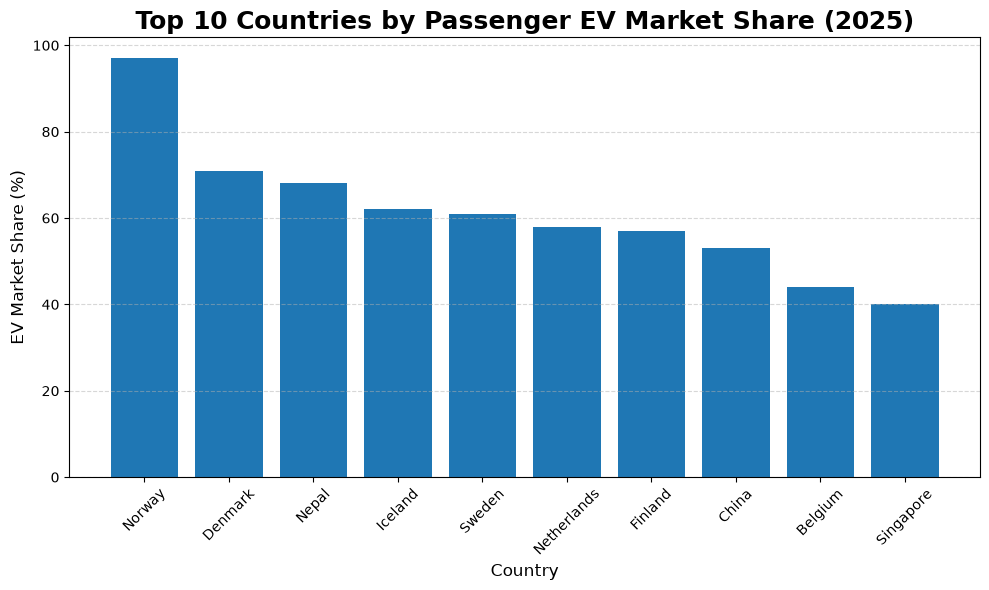

In [35]:
import matplotlib.pyplot as plt

top10 = market_share.head(10)

plt.figure(figsize=(10,6))

plt.bar(top10["region_country"], top10["value"])

plt.title("Top 10 Countries by Passenger EV Market Share (2025)", fontsize=18, weight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("EV Market Share (%)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 📊 Business Insights

• Norway leads the world with the highest passenger EV market share in 2025.

• Nordic countries dominate the rankings, reflecting strong government incentives and charging infrastructure.

• China ranks among the leading large automobile markets with high EV adoption.

• High market share indicates faster transition from internal combustion vehicles to electric mobility.

• Countries with strong policy support and infrastructure achieve significantly higher EV adoption rates.

In [36]:
ev.to_csv("EV_Cleaned_Data.csv", index=False)

print("CSV exported successfully!")

CSV exported successfully!
